# Trader Performance vs Market Sentiment Analysis  


**Objective:**  
This project analyzes how Bitcoin market sentiment (Fear vs Greed) relates to trader behavior and performance on Hyperliquid.  
The goal is to identify whether sentiment impacts profitability, leverage, trade frequency, and directional bias, and to propose actionable trading rules based on the findings.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
# Plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

# Load Data

In [3]:
trades_path = "historical_data.csv"
sentiment_path = "fear_greed_index.csv"
trades_df = pd.read_csv(trades_path)
sentiment_df = pd.read_csv(sentiment_path)

print("Historical Trader Data Shape:", trades_df.shape)
print("Fear & Greed Data Shape:", sentiment_df.shape)

print("\nHistorical Trader Data Columns:")
print(trades_df.columns.tolist())

print("\nFear & Greed Data Columns:")
print(sentiment_df.columns.tolist())

Historical Trader Data Shape: (211224, 16)
Fear & Greed Data Shape: (2644, 4)

Historical Trader Data Columns:
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

Fear & Greed Data Columns:
['timestamp', 'value', 'classification', 'date']


 # Data Cleaning

In [4]:
def data_quality_report(df, name):
    print(f"\n{'='*60}")
    print(f"Data Quality Report: {name}")
    print(f"{'='*60}")
    print(f"Rows, Columns: {df.shape}")
    
    print("\nMissing Values:")
    print(df.isnull().sum())
    
    print("\nDuplicate Rows:", df.duplicated().sum())
    
    print("\nSample Data:")
    display(df.head())

data_quality_report(trades_df, "Historical Trader Data")
data_quality_report(sentiment_df, "Fear & Greed Index")


Data Quality Report: Historical Trader Data
Rows, Columns: (211224, 16)

Missing Values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicate Rows: 0

Sample Data:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12



Data Quality Report: Fear & Greed Index
Rows, Columns: (2644, 4)

Missing Values:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicate Rows: 0

Sample Data:


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [5]:
trades_df["Timestamp IST"] = pd.to_datetime(
    trades_df["Timestamp IST"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

# Create daily trade date
trades_df["trade_date"] = trades_df["Timestamp IST"].dt.date

# Parse sentiment date
sentiment_df["date"] = pd.to_datetime(sentiment_df["date"], errors="coerce").dt.date

# Check parsing success
print("Null timestamps in trades:", trades_df["Timestamp IST"].isnull().sum())
print("Null dates in sentiment:", sentiment_df["date"].isnull().sum())

Null timestamps in trades: 0
Null dates in sentiment: 0


In [6]:
def simplify_sentiment(x):
    x = str(x).strip().lower()
    if "fear" in x:
        return "Fear"
    elif "greed" in x:
        return "Greed"
    else:
        return "Neutral"

# The column name in your file is likely 'classification'
# If needed, adjust below after checking sentiment_df.columns
sentiment_df["sentiment_group"] = sentiment_df["classification"].apply(simplify_sentiment)

# Keep only required columns for merge
sentiment_clean = sentiment_df[["date", "classification", "sentiment_group", "value"]].copy()

display(sentiment_clean.head())
print(sentiment_clean["sentiment_group"].value_counts())

,date,classification,sentiment_group,value
0,2018-02-01,Fear,Fear,30
1,2018-02-02,Extreme Fear,Fear,15
2,2018-02-03,Fear,Fear,40
3,2018-02-04,Extreme Fear,Fear,24
4,2018-02-05,Extreme Fear,Fear,11


sentiment_group
Fear       1289
Greed       959
Neutral     396
Name: count, dtype: int64


# Merging Datasets

In [7]:
merged_df = trades_df.merge(
    sentiment_clean,
    left_on="trade_date",
    right_on="date",
    how="left"
)

print("Merged Data Shape:", merged_df.shape)
print("\nMissing sentiment after merge:")
print(merged_df["sentiment_group"].isnull().sum())

display(merged_df.head())

Merged Data Shape: (211224, 21)

Missing sentiment after merge:
6


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,trade_date,date,classification,sentiment_group,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,2024-12-02,Extreme Greed,Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,2024-12-02,Extreme Greed,Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,2024-12-02,Extreme Greed,Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,2024-12-02,Extreme Greed,Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,2024-12-02,Extreme Greed,Greed,80.0


In [14]:
print("Merged columns:")
print(merged_df.columns.tolist())
numeric_cols = ["Execution Price", "Size Tokens", "Size USD", "Closed PnL", "leverage", "Leverage"]

for col in numeric_cols:
    if col in merged_df.columns:
        merged_df[col] = pd.to_numeric(merged_df[col], errors="coerce")

# Detect leverage column automatically
if "Leverage" in merged_df.columns:
    leverage_col = "Leverage"
elif "leverage" in merged_df.columns:
    leverage_col = "leverage"
else:
    leverage_col = None
    print("⚠️ Leverage column not found")

# Detect account column automatically
if "account" in merged_df.columns:
    account_col = "account"
elif "Account" in merged_df.columns:
    account_col = "Account"
else:
    account_col = None
    print("⚠️ Account column not found")
merged_df["pnl_flag"] = np.where(merged_df["Closed PnL"] > 0, 1, 0)
merged_df["Side"] = merged_df["Side"].astype(str).str.lower().str.strip()
def map_direction(side):
    if "buy" in side or "long" in side:
        return "Long"
    elif "sell" in side or "short" in side:
        return "Short"
    else:
        return "Other"

merged_df["trade_direction"] = merged_df["Side"].apply(map_direction)

# Absolute trade size
merged_df["trade_size_abs"] = merged_df["Size USD"].abs()

# Quick check (safe)
preview_cols = [
    account_col,
    "trade_date",
    "Closed PnL",
    "pnl_flag",
    "trade_direction",
    "trade_size_abs",
    "sentiment_group"
]

if leverage_col:
    preview_cols.append(leverage_col)

display(merged_df[preview_cols].head())

Merged columns:
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'trade_date', 'date', 'classification', 'sentiment_group', 'value', 'pnl_flag', 'trade_direction', 'trade_size_abs']
⚠️ Leverage column not found


,Account,trade_date,Closed PnL,pnl_flag,trade_direction,trade_size_abs,sentiment_group
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,0.0,0,Long,7872.16,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,0.0,0,Long,127.68,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,0.0,0,Long,1150.63,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,0.0,0,Long,1142.04,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,0.0,0,Long,69.75,Greed


In [9]:
print("TRADES COLUMNS:")
print(trades_df.columns.tolist())

print("\nMERGED COLUMNS:")
print(merged_df.columns.tolist())

TRADES COLUMNS:
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'trade_date']

MERGED COLUMNS:
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'trade_date', 'date', 'classification', 'sentiment_group', 'value', 'pnl_flag', 'trade_direction', 'trade_size_abs']


In [12]:
# Standardize column names (recommended)
trades_df.columns = trades_df.columns.str.strip()
sentiment_df.columns = sentiment_df.columns.str.strip()

print("Trades columns:")
print(trades_df.columns.tolist())

print("\nSentiment columns:")
print(sentiment_df.columns.tolist())

Trades columns:
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'trade_date']

Sentiment columns:
['timestamp', 'value', 'classification', 'date', 'sentiment_group']


In [19]:
daily_account = (
    merged_df
    .groupby(["Account", "trade_date", "sentiment_group"], as_index=False)
    .agg(
        daily_pnl=("Closed PnL", "sum"),
        win_rate=("pnl_flag", "mean"),
        avg_trade_size=("trade_size_abs", "mean"),
        trade_count=("Account", "size"),
        long_ratio=("trade_direction", lambda x: (x == "Long").mean()),
        short_ratio=("trade_direction", lambda x: (x == "Short").mean())
    )
)

# Profitable day flag
daily_account["profitable_day"] = np.where(daily_account["daily_pnl"] > 0, 1, 0)

print("Daily Account-Level Dataset Shape:", daily_account.shape)
display(daily_account.head())

Daily Account-Level Dataset Shape: (2340, 10)


,Account,trade_date,sentiment_group,daily_pnl,win_rate,avg_trade_size,trade_count,long_ratio,short_ratio,profitable_day
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Greed,0.0,0.000000,5089.718249,177,0.000000,1.000000,0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Greed,0.0,0.000000,7976.664412,68,0.000000,1.000000,0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Greed,0.0,0.000000,23734.500000,40,0.000000,1.000000,0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Greed,-21227.0,0.000000,28186.666667,12,1.000000,0.000000,0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Greed,1603.1,0.444444,17248.148148,27,0.444444,0.555556,1


# Creating Daily Account-Level Dataset

In [20]:
daily_account = (
    merged_df
    .groupby(["Account", "trade_date", "sentiment_group"], as_index=False)
    .agg(
        daily_pnl=("Closed PnL", "sum"),
        win_rate=("pnl_flag", "mean"),
        avg_trade_size=("trade_size_abs", "mean"),
        trade_count=("Account", "size"),
        long_ratio=("trade_direction", lambda x: (x == "Long").mean()),
        short_ratio=("trade_direction", lambda x: (x == "Short").mean())
    )
)

# Create profitable day flag
daily_account["profitable_day"] = np.where(daily_account["daily_pnl"] > 0, 1, 0)

print("Daily Account-Level Dataset Shape:", daily_account.shape)
display(daily_account.head())

Daily Account-Level Dataset Shape: (2340, 10)


,Account,trade_date,sentiment_group,daily_pnl,win_rate,avg_trade_size,trade_count,long_ratio,short_ratio,profitable_day
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Greed,0.0,0.000000,5089.718249,177,0.000000,1.000000,0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Greed,0.0,0.000000,7976.664412,68,0.000000,1.000000,0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Greed,0.0,0.000000,23734.500000,40,0.000000,1.000000,0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Greed,-21227.0,0.000000,28186.666667,12,1.000000,0.000000,0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Greed,1603.1,0.444444,17248.148148,27,0.444444,0.555556,1


# Large vs Small Trade Size Traders

In [22]:
account_trade_size = (
    merged_df.groupby("Account", as_index=False)
    .agg(account_avg_trade_size=("trade_size_abs", "mean"))
)

# Median threshold
trade_size_median = account_trade_size["account_avg_trade_size"].median()

# Segment traders
account_trade_size["trade_size_segment"] = np.where(
    account_trade_size["account_avg_trade_size"] >= trade_size_median,
    "Large Trade Size",
    "Small Trade Size"
)

# Merge segment into daily dataset
daily_account = daily_account.merge(
    account_trade_size[["Account", "trade_size_segment"]],
    on="Account",
    how="left"
)

# Summary table
trade_size_segment_summary = (
    daily_account
    .groupby(["trade_size_segment", "sentiment_group"], as_index=False)
    .agg(
        avg_daily_pnl=("daily_pnl", "mean"),
        median_daily_pnl=("daily_pnl", "median"),
        avg_win_rate=("win_rate", "mean"),
        avg_trade_count=("trade_count", "mean")
    )
)

trade_size_segment_summary["avg_win_rate"] *= 100

print("Trade Size Segment Summary")
display(trade_size_segment_summary.round(2))

Trade Size Segment Summary


,trade_size_segment,sentiment_group,avg_daily_pnl,median_daily_pnl,avg_win_rate,avg_trade_count
0,Large Trade Size,Fear,7620.02,212.08,32.87,91.55
1,Large Trade Size,Greed,5647.12,34.69,29.50,45.20
2,Large Trade Size,Neutral,6302.68,174.74,32.18,69.65
3,Small Trade Size,Fear,3354.94,100.22,37.84,115.75
4,Small Trade Size,Greed,2881.57,414.75,41.96,103.55
5,Small Trade Size,Neutral,1125.34,167.55,38.26,124.92


# Frequent vs Infrequent Traders

In [23]:
account_frequency = (
    merged_df.groupby("Account", as_index=False)
    .agg(total_trades=("Account", "size"))
)

# Median threshold
freq_median = account_frequency["total_trades"].median()

# Segment traders
account_frequency["frequency_segment"] = np.where(
    account_frequency["total_trades"] >= freq_median,
    "Frequent Trader",
    "Infrequent Trader"
)

# Merge segment into daily dataset
daily_account = daily_account.merge(
    account_frequency[["Account", "frequency_segment"]],
    on="Account",
    how="left"
)

# Summary table
frequency_segment_summary = (
    daily_account
    .groupby(["frequency_segment", "sentiment_group"], as_index=False)
    .agg(
        avg_daily_pnl=("daily_pnl", "mean"),
        median_daily_pnl=("daily_pnl", "median"),
        avg_win_rate=("win_rate", "mean"),
        avg_trade_count=("trade_count", "mean")
    )
)

frequency_segment_summary["avg_win_rate"] *= 100

print("Frequency Segment Summary")
display(frequency_segment_summary.round(2))

Frequency Segment Summary


,frequency_segment,sentiment_group,avg_daily_pnl,median_daily_pnl,avg_win_rate,avg_trade_count
0,Frequent Trader,Fear,5968.41,195.61,37.26,126.11
1,Frequent Trader,Greed,3846.86,444.90,37.57,92.75
2,Frequent Trader,Neutral,3978.07,278.14,37.83,115.04
3,Infrequent Trader,Fear,3090.37,0.00,31.56,49.87
4,Infrequent Trader,Greed,4987.66,0.00,32.61,31.99
5,Infrequent Trader,Neutral,1473.94,0.00,27.20,46.28


# Consistent Winners vs Inconsistent Traders

In [24]:
account_consistency = (
    daily_account.groupby("Account", as_index=False)
    .agg(
        profitable_day_rate=("profitable_day", "mean"),
        avg_daily_pnl=("daily_pnl", "mean")
    )
)

# Median threshold
consistency_threshold = account_consistency["profitable_day_rate"].median()

# Segment traders
account_consistency["consistency_segment"] = np.where(
    account_consistency["profitable_day_rate"] >= consistency_threshold,
    "Consistent Winner",
    "Inconsistent Trader"
)

# Merge segment into daily dataset
daily_account = daily_account.merge(
    account_consistency[["Account", "consistency_segment"]],
    on="Account",
    how="left"
)

# Summary table
consistency_segment_summary = (
    daily_account
    .groupby(["consistency_segment", "sentiment_group"], as_index=False)
    .agg(
        avg_daily_pnl=("daily_pnl", "mean"),
        median_daily_pnl=("daily_pnl", "median"),
        avg_win_rate=("win_rate", "mean"),
        avg_trade_count=("trade_count", "mean")
    )
)

consistency_segment_summary["avg_win_rate"] *= 100

print("Consistency Segment Summary")
display(consistency_segment_summary.round(2))

Consistency Segment Summary


,consistency_segment,sentiment_group,avg_daily_pnl,median_daily_pnl,avg_win_rate,avg_trade_count
0,Consistent Winner,Fear,6526.01,236.10,39.02,135.59
1,Consistent Winner,Greed,2992.82,510.00,39.74,93.28
2,Consistent Winner,Neutral,3208.64,336.64,42.25,123.43
3,Inconsistent Trader,Fear,2995.07,0.00,30.29,55.99
4,Inconsistent Trader,Greed,6158.46,0.00,30.22,48.27
5,Inconsistent Trader,Neutral,3858.80,0.00,23.28,57.83


In [25]:
trade_size_segment_summary["segment_type"] = "Trade Size"
frequency_segment_summary["segment_type"] = "Frequency"
consistency_segment_summary["segment_type"] = "Consistency"

combined_segments = pd.concat([
    trade_size_segment_summary.rename(columns={"trade_size_segment": "segment_name"}),
    frequency_segment_summary.rename(columns={"frequency_segment": "segment_name"}),
    consistency_segment_summary.rename(columns={"consistency_segment": "segment_name"})
], ignore_index=True)

print("Combined Segment Comparison")
display(combined_segments.round(2))

Combined Segment Comparison


,segment_name,sentiment_group,avg_daily_pnl,median_daily_pnl,avg_win_rate,avg_trade_count,segment_type
0,Large Trade Size,Fear,7620.02,212.08,32.87,91.55,Trade Size
1,Large Trade Size,Greed,5647.12,34.69,29.50,45.20,Trade Size
2,Large Trade Size,Neutral,6302.68,174.74,32.18,69.65,Trade Size
3,Small Trade Size,Fear,3354.94,100.22,37.84,115.75,Trade Size
4,Small Trade Size,Greed,2881.57,414.75,41.96,103.55,Trade Size
5,Small Trade Size,Neutral,1125.34,167.55,38.26,124.92,Trade Size
6,Frequent Trader,Fear,5968.41,195.61,37.26,126.11,Frequency
7,Frequent Trader,Greed,3846.86,444.90,37.57,92.75,Frequency
8,Frequent Trader,Neutral,3978.07,278.14,37.83,115.04,Frequency
9,Infrequent Trader,Fear,3090.37,0.00,31.56,49.87,Frequency


# Average Daily PnL by Sentiment Group

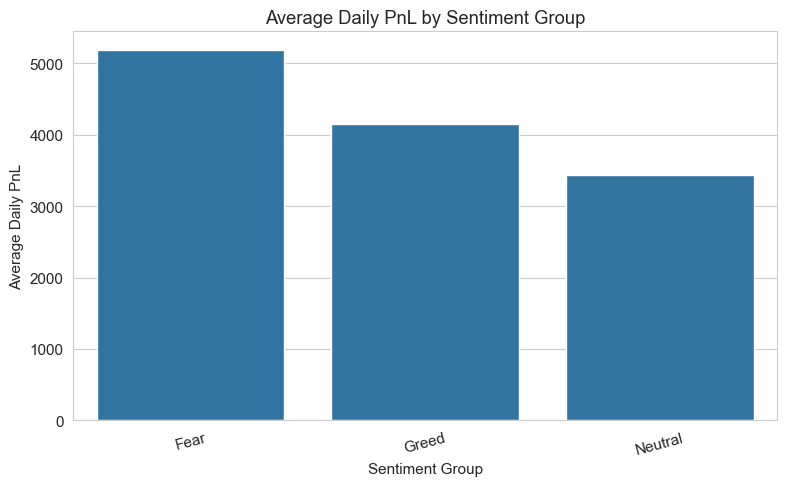

In [26]:
sentiment_pnl = (
    daily_account.groupby("sentiment_group", as_index=False)
    .agg(avg_daily_pnl=("daily_pnl", "mean"))
)

plt.figure(figsize=(8, 5))
sns.barplot(data=sentiment_pnl, x="sentiment_group", y="avg_daily_pnl")
plt.title("Average Daily PnL by Sentiment Group")
plt.xlabel("Sentiment Group")
plt.ylabel("Average Daily PnL")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Win Rate by Sentiment Group

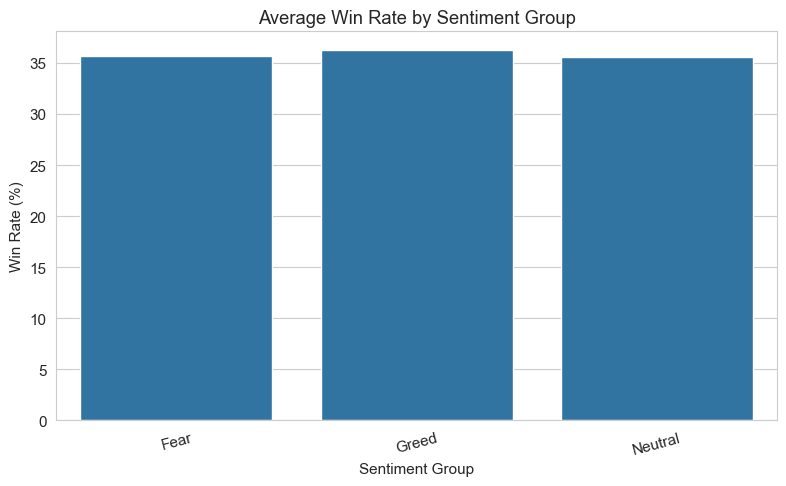

In [27]:
sentiment_winrate = (
    daily_account.groupby("sentiment_group", as_index=False)
    .agg(avg_win_rate=("win_rate", "mean"))
)

sentiment_winrate["avg_win_rate"] = sentiment_winrate["avg_win_rate"] * 100

plt.figure(figsize=(8, 5))
sns.barplot(data=sentiment_winrate, x="sentiment_group", y="avg_win_rate")
plt.title("Average Win Rate by Sentiment Group")
plt.xlabel("Sentiment Group")
plt.ylabel("Win Rate (%)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Average Daily PnL by Trade Size Segment

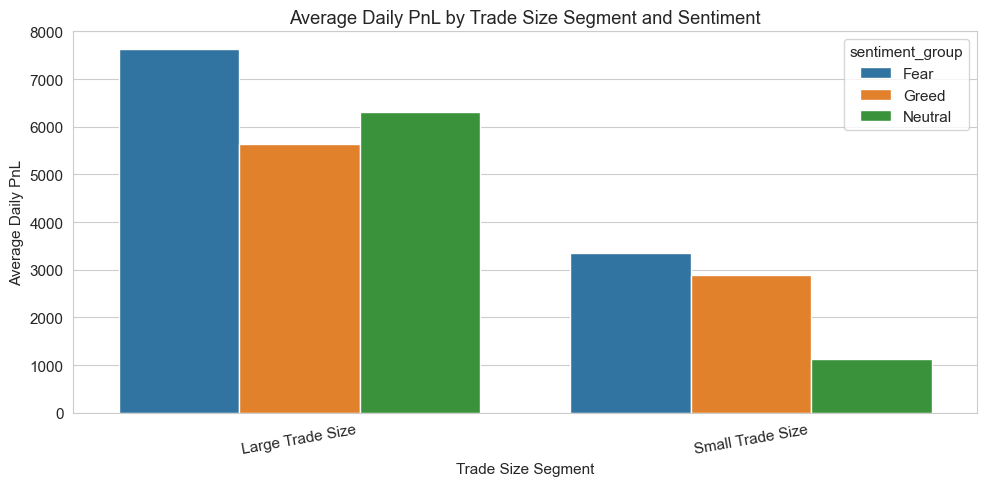

In [28]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=trade_size_segment_summary,
    x="trade_size_segment",
    y="avg_daily_pnl",
    hue="sentiment_group"
)
plt.title("Average Daily PnL by Trade Size Segment and Sentiment")
plt.xlabel("Trade Size Segment")
plt.ylabel("Average Daily PnL")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

# Average Daily PnL by Frequency Segment

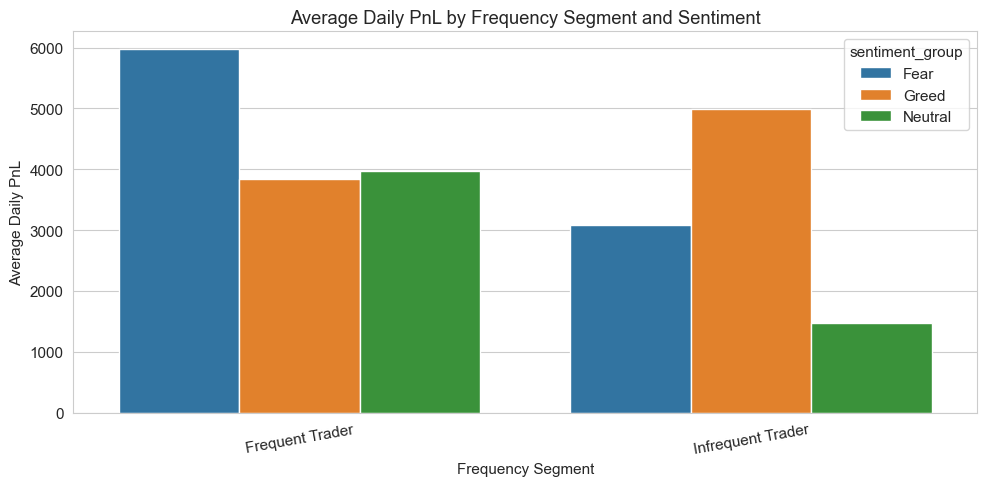

In [30]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=frequency_segment_summary,
    x="frequency_segment",
    y="avg_daily_pnl",
    hue="sentiment_group"
)
plt.title("Average Daily PnL by Frequency Segment and Sentiment")
plt.xlabel("Frequency Segment")
plt.ylabel("Average Daily PnL")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

# Average Daily PnL by Consistency Segment

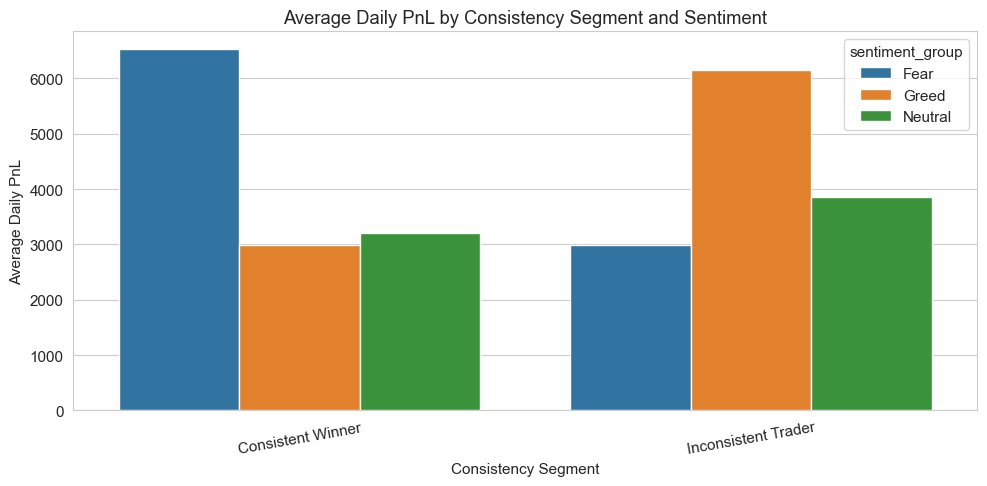

In [31]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=consistency_segment_summary,
    x="consistency_segment",
    y="avg_daily_pnl",
    hue="sentiment_group"
)
plt.title("Average Daily PnL by Consistency Segment and Sentiment")
plt.xlabel("Consistency Segment")
plt.ylabel("Average Daily PnL")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

# Correlation Analysis

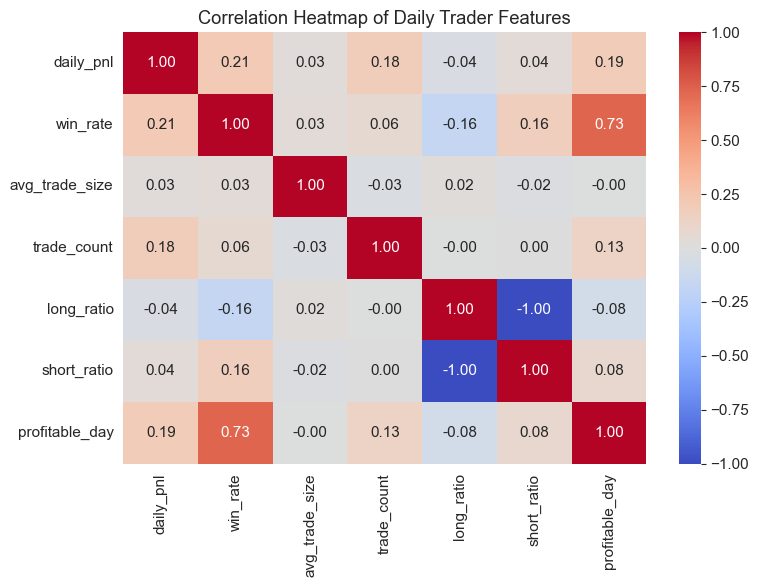

In [32]:
corr_df = daily_account[[
    "daily_pnl", "win_rate", "avg_trade_size", "trade_count", "long_ratio", "short_ratio", "profitable_day"
]].copy()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Daily Trader Features")
plt.tight_layout()
plt.show()

# Key TakeAways

In [36]:
print("KEY TAKEAWAYS")
print("-" * 50)
best_sentiment = sentiment_pnl.sort_values("avg_daily_pnl", ascending=False).iloc[0]
print(f"1. Highest average daily PnL was observed under sentiment group: {best_sentiment['sentiment_group']}")

best_winrate = sentiment_winrate.sort_values("avg_win_rate", ascending=False).iloc[0]
print(f"2. Highest average win rate was observed under sentiment group: {best_winrate['sentiment_group']}")

best_trade_size = trade_size_segment_summary.sort_values("avg_daily_pnl", ascending=False).iloc[0]
print(f"3. Best trade-size segment performance: {best_trade_size['trade_size_segment']} under {best_trade_size['sentiment_group']} sentiment")

best_frequency = frequency_segment_summary.sort_values("avg_daily_pnl", ascending=False).iloc[0]
print(f"4. Best frequency segment performance: {best_frequency['frequency_segment']} under {best_frequency['sentiment_group']} sentiment")

best_consistency = consistency_segment_summary.sort_values("avg_daily_pnl", ascending=False).iloc[0]
print(f"5. Best consistency segment performance: {best_consistency['consistency_segment']} under {best_consistency['sentiment_group']} sentiment")

KEY TAKEAWAYS
--------------------------------------------------
1. Highest average daily PnL was observed under sentiment group: Fear
2. Highest average win rate was observed under sentiment group: Greed
3. Best trade-size segment performance: Large Trade Size under Fear sentiment
4. Best frequency segment performance: Frequent Trader under Fear sentiment
5. Best consistency segment performance: Consistent Winner under Fear sentiment


In [37]:
daily_account.to_csv("final_trader_daily_features.csv", index=False)
combined_segments.to_csv("segment_comparison_summary.csv", index=False)

print("Files exported successfully:")
print("- final_trader_daily_features.csv")
print("- segment_comparison_summary.csv")

Files exported successfully:
- final_trader_daily_features.csv
- segment_comparison_summary.csv
